# **Model Comparison**

## Load Data

In [1]:
import pandas as pd
import sys

sys.path.append("../src")
from evaluation import evaluate_model

df = pd.read_csv("../data/processed/loan_clean.csv")

## Stratified Split

In [2]:
from split import train_test_split_data

X_train, X_test, y_train, y_test = train_test_split_data(df)

In [3]:
# Default rate check
print("Train default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Train default rate: 0.1996259226497982
Test default rate: 0.1996268518036735


## *Model 1: Logistic Regression*

In [4]:
# scaling features for logistic regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from model_LR import *

model_lr = train_logistic(X_train_scaled, y_train)

# PD prediction
y_pred_lr = predict_pd(model_lr, X_test_scaled)

# evaluation
metrics_lr = evaluate_model(y_test, y_pred_lr)

## *Model 2: Random Forrest (✅)*

In [6]:
from model_RF import *

model_rf = train_rf(X_train, y_train)

# PD prediction
y_pred_rf = predict_pd_rf(model_rf, X_test)

# evaluation
metrics_rf = evaluate_model(y_test, y_pred_rf)

## Model Comparison

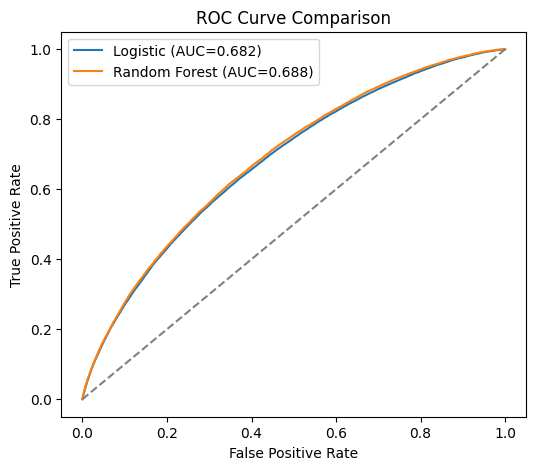

In [7]:
# ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# LR
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)

# RF
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC={metrics_lr['AUC']:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={metrics_rf['AUC']:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

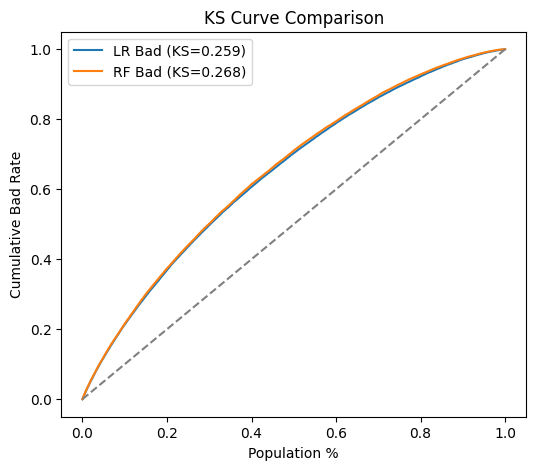

In [8]:
# KS curve
import numpy as np
import pandas as pd


def plot_ks(y_true, y_pred, label):

    data = pd.DataFrame({"y": y_true, "pd": y_pred})

    data = data.sort_values("pd", ascending=False)

    data["cum_bad"] = data["y"].cumsum() / data["y"].sum()
    data["cum_good"] = (1 - data["y"]).cumsum() / (1 - data["y"]).sum()
    data["pct"] = np.arange(len(data)) / len(data)

    ks = np.max(data["cum_bad"] - data["cum_good"])

    return data["pct"], data["cum_bad"], data["cum_good"], ks


plt.figure(figsize=(6, 5))

# LR
pct_lr, bad_lr, good_lr, ks_lr = plot_ks(y_test, y_pred_lr, "LR")

# RF
pct_rf, bad_rf, good_rf, ks_rf = plot_ks(y_test, y_pred_rf, "RF")

plt.plot(pct_lr, bad_lr, label=f"LR Bad (KS={ks_lr:.3f})")
plt.plot(pct_rf, bad_rf, label=f"RF Bad (KS={ks_rf:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("Population %")
plt.ylabel("Cumulative Bad Rate")
plt.title("KS Curve Comparison")
plt.legend()
plt.show()

Logistic Regression and Random Forest exhibit similar discriminatory power, with Random Forest only marginally outperforming Logistic Regression.

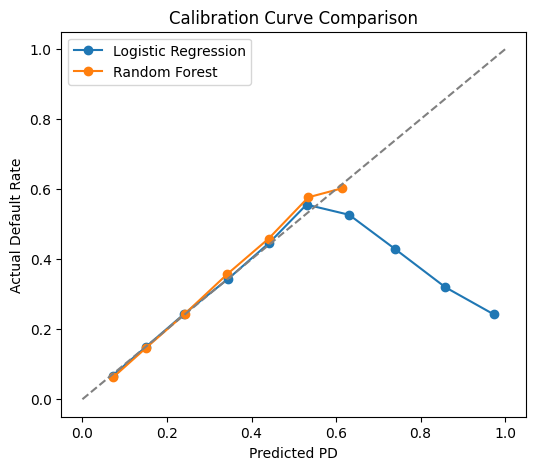

In [ ]:
# Calibration curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# LR
prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_pred_lr, n_bins=10)

# RF
prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_pred_rf, n_bins=10)

plt.figure(figsize=(6, 5))

plt.plot(prob_pred_lr, prob_true_lr, marker="o", label="Logistic Regression")
plt.plot(prob_pred_rf, prob_true_rf, marker="o", label="Random Forest")

# perfect calibration line
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("Predicted PD")
plt.ylabel("Actual Default Rate")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.show()

However, Random Forest demonstrates better calibration, particularly in the high-risk region, while Logistic Regression significantly underestimates default probabilities for high-risk borrowers.

## Feature Importance

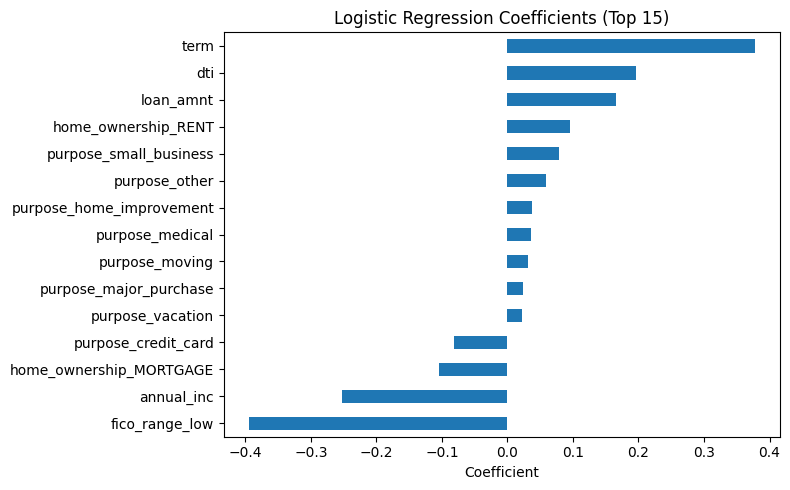

In [ ]:
coef_lr = pd.Series(model_lr.coef_[0], index=X_train.columns)

coef_lr = coef_lr.reindex(coef_lr.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 5))
coef_lr.head(15).sort_values().plot(kind="barh")

plt.title("Logistic Regression Coefficients (Top 15)")
plt.xlabel("Coefficient")

plt.tight_layout()
plt.show()

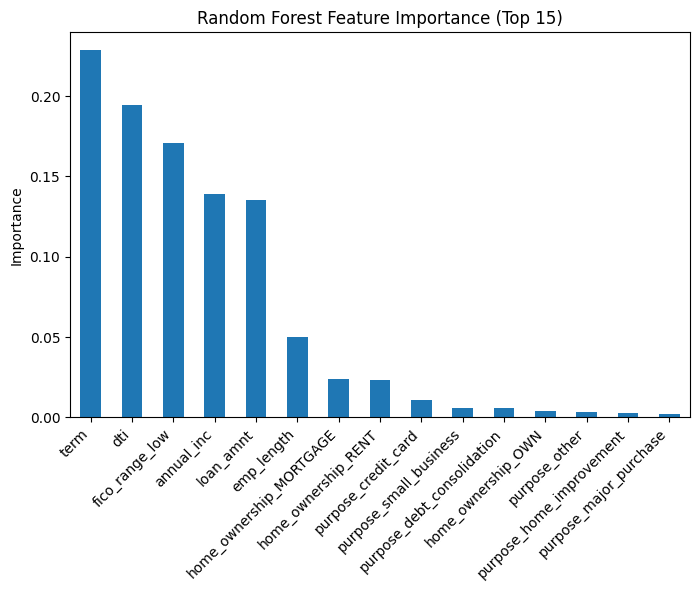

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# feature importance
importances = model_rf.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

# plot
plt.figure(figsize=(8, 5))
feat_imp.head(15).plot(kind="bar")
plt.title("Random Forest Feature Importance (Top 15)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

Although Logistic Regression and Random Forest show similar performance in terms of AUC and KS, Random Forest demonstrates slightly better predictive power.

More importantly, Random Forest provides superior calibration, particularly in the high-risk segment, while Logistic Regression tends to underestimate default probabilities for high-risk borrowers.

Since accurate probability estimation is critical in credit risk modeling, Random Forest is selected as the final model.

## PD OUTPUT

In [17]:
# PD Output (use Random Forest predictions)

results = X_test.copy()

results["actual_default"] = y_test.values
results["predicted_pd"] = y_pred_rf

results.sample(10)

,loan_amnt,annual_inc,fico_range_low,dti,emp_length,term,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,...,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,actual_default,predicted_pd
495440,6000.0,25000.0,675.0,9.83,6.0,36.0,False,False,False,False,...,False,False,False,False,False,False,False,False,1,0.219190
1057091,7000.0,134400.0,675.0,16.26,1.0,36.0,False,False,False,False,...,False,False,False,True,False,False,False,False,0,0.190940
409466,4800.0,73209.0,685.0,12.95,5.0,36.0,True,False,False,False,...,False,False,False,False,False,False,False,False,0,0.102099
351227,32500.0,65000.0,735.0,13.62,9.0,60.0,True,False,False,False,...,False,False,False,False,False,False,False,False,1,0.186374
1324433,18275.0,60000.0,715.0,23.08,2.0,36.0,False,False,False,True,...,False,False,False,False,False,False,False,False,0,0.164380
788407,4200.0,42000.0,680.0,26.49,9.0,36.0,False,False,False,False,...,False,False,False,False,False,False,False,False,0,0.237798
255834,7325.0,21600.0,675.0,21.28,0.0,36.0,False,False,False,False,...,False,False,False,True,False,False,False,False,1,0.265080
1329131,15000.0,60000.0,675.0,6.74,7.0,60.0,False,False,False,False,...,False,False,False,False,False,False,False,False,0,0.371234
268359,24000.0,125000.0,690.0,20.87,5.0,36.0,True,False,False,False,...,False,False,False,False,False,False,False,False,0,0.143404
213813,9200.0,20000.0,700.0,20.68,6.0,36.0,False,False,False,False,...,False,False,False,False,False,False,False,False,0,0.267836


In [15]:
results.to_csv("../data/processed/test_with_pd_rf.csv", index=False)